In [1]:
import sys
import os
sys.path.append("../..")

import numpy as np
import csv
import torch
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, ThreadDataLoader
from monai.data.utils import pad_list_data_collate
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import random
from torch.utils.tensorboard import SummaryWriter
import yaml

import utils.custom_transforms as custom_transforms

from spark.Spark_2D import SparK_2D 

/bettik/PROJECTS/pr-gin5_aini/fehrdelt/environments/ddpm_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing from timm.models.layers is deprecated, please import via timm.layers


`pip install timm`

In [2]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
EXPERIMENT_NAME = "experiment_cDDPM_spark2D_AE"
SUB_EXPERIMENT_NAME = "cDDPM_0"
MODELS_DIR = ROOT_DIR+f"AnoDiffExperiments/{EXPERIMENT_NAME}/{SUB_EXPERIMENT_NAME}/models/"
os.makedirs(MODELS_DIR, exist_ok=True)

# Guided reconstruction with conditioned diffusion models for unsupervised anomaly detection in brain MRIs

https://www.sciencedirect.com/science/article/pii/S0010482525000101

https://github.com/FinnBehrendt/Conditioned-Diffusion-Models-UAD

### Encoder conditioner : patch training from Spark2D autoencoder (Designing BERT for Convolutional Networks: Sparse and Hierarchical Masked Modeling)


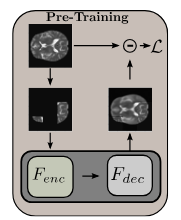

In [13]:
torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)

### Data

In [ ]:
train_csv = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/train.csv")
train_images_path = []

with open(train_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        train_images_path.append(ROOT_DIR+line[0])

val_csv = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/val.csv")
val_images_path = []

with open(val_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        val_images_path.append(ROOT_DIR+line[0])

#train_datalist = sorted(train_images_path)
train_datalist = train_images_path

#val_datalist = sorted(val_images_path)
val_datalist = val_images_path

#test_unhealthy_datalist = test_unhealthy_images_path

batch_size = 32
num_workers = 8



train_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        transforms.RandAffine(prob=0.5, rotate_range=[0.1, 0.1, 0.1]),
        custom_transforms.Get2DSliceWithRandomOffset(axis=2, fixed_offset=0, range_offset=3),
        transforms.RandScaleCrop(roi_scale=0.9, max_roi_scale=1.1, random_size=True),
        transforms.ResizeWithPadOrCrop(spatial_size=[128, 128]),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=450.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.RandFlip(prob=0.5, spatial_axis=0),
        transforms.RandSpatialCrop([72,72]), # according to the paper, they use a mask-out ratio of 65% during the autoencoder training
        custom_transforms.SetBackgroundToZero()
    ]
)
train_ds = CacheDataset(data=train_datalist, transform=train_transforms)


val_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        custom_transforms.Get2DSlice(axis=2),
        transforms.ResizeWithPadOrCrop(spatial_size=[128, 128]),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=450.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero()
    ]
)
val_ds = CacheDataset(data=val_datalist, transform=val_transforms)


""" train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
) """
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

758it [00:00, 204481.76it/s]
95it [00:00, 52846.01it/s]
Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [00:06<00:00, 14.53it/s]


### Model

In [4]:
# Load the YAML file
with open(f'{ROOT_DIR}/AnoDiffExperiments/2d_cddpm/2d_ddpm_cond_spark.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

In [5]:
model = SparK_2D(cfg)

[sparse_cnn] model kwargs={'drop_path_rate': 0.05, 'pretrained': False, 'num_classes': 0, 'global_pool': ''}
[mid, py=4][edl 0]: k=1, #para = 1.05
[mid, py=4][edl 1]: k=3, #para = 2.36
[mid, py=4][edl 2]: k=3, #para = 0.59
[mid, py=4][edl 3]: k=3, #para = 0.15
[mid, py=4][mask_tokens]: (2048, 1024, 512, 256)


In [6]:
class L1_AE(torch.nn.Module):
    def __init__(self) :
        super().__init__()
        self.strat = "mean"

    def forward(self, output_batch, input_batch) :
        if isinstance(output_batch, dict):
            output_batch = output_batch['x_hat']
        else: 
            output_batch = output_batch
        if self.strat == 'sum' :
            L1Loss = torch.nn.L1Loss(reduction = 'sum') 
            L1 = L1Loss(output_batch, input_batch)/input_batch.shape[0]
        elif self.strat == 'mean' :
            L1Loss = torch.nn.L1Loss(reduction = 'mean') 
            L1 = L1Loss(output_batch, input_batch)
        loss = {}
        loss['combined_loss'] = L1
        loss['reg'] = L1 # dummy
        loss['recon_error'] = L1 
        return loss 

### Training

In [7]:
device = torch.cuda.set_device("cuda:0")

In [8]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)
scaler = GradScaler("cuda")
L1 = L1_AE()

In [ ]:
writer = SummaryWriter(ROOT_DIR+f"AnoDiffExperiments/tensorboard/{SUB_EXPERIMENT_NAME}")
max_epochs=2000
val_interval=5

best_val_epoch_loss = np.inf
best_val_epoch = 0


for epoch in range(max_epochs):
    model.train()


    epoch_loss = 0
    

    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=70)
    progress_bar.set_description(f"Epoch {epoch}")

    for step, batch in progress_bar:
    #for step, batch in enumerate(train_loader):
        images = batch.to(device)
        
        optimizer.zero_grad(set_to_none=True)

        active_ex, reco, loss, latent = model(images)
        loss = L1({'x_hat':reco},images)['recon_error'] + cfg.get('delta_mask',0) * loss 

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        

        progress_bar.set_postfix({"loss": epoch_loss / (step + 1)})


    writer.add_scalar("train_loss", epoch_loss / (step + 1), epoch)

    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_epoch_loss = 0
        for step, batch in enumerate(val_loader):
            images = batch.to(device)
            
            active_ex, reco, val_loss, latent = model(images)
            val_loss = L1({'x_hat':reco},images)['recon_error'] + cfg.get('delta_mask',0) * val_loss 

            val_epoch_loss += val_loss.item()

            progress_bar.set_postfix({"val_loss": val_epoch_loss / (step + 1)})

        writer.add_scalar("val_loss", val_epoch_loss / (step + 1), epoch)

        if val_epoch_loss < best_val_epoch_loss:
            best_val_epoch_loss = val_epoch_loss
            best_val_epoch = epoch + 1

            torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{SUB_EXPERIMENT_NAME}_spark2D_AE_best_model.pth"))

            print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current val loss: {val_epoch_loss/(step + 1):.4f}"
                f"\nbest val loss: {best_val_epoch_loss/(step + 1):.4f}"
                f" at epoch: {best_val_epoch}"
            )
            writer.add_scalar("best_val_loss", best_val_epoch_loss/(step + 1), best_val_epoch)

            # can't visualize an inference image since we don't train from pure noise here
            #noise = generate_simplex_noise(simplexObj, shape=(1,1,IMAGE_SIZE, IMAGE_SIZE)).to(device)
            #noise = noise.to(device)
            #scheduler.set_timesteps(num_inference_steps=1000)
            #with autocast(device_type=DEVICE_TYPE, enabled=True):
            #    image = inferer.sample(input_noise=noise, diffusion_model=model, scheduler=scheduler)
            #writer.add_image("sampled_image", image[0, 0].cpu().numpy(), global_step=epoch, dataformats="HW")
            #plt.figure(figsize=(2, 2))
            #plt.imshow(image[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
            #plt.tight_layout()
            #plt.axis("off")
            #plt.show()
    
print(f"Training complete, best val loss: {best_val_epoch_loss/(step + 1)} at epoch {best_val_epoch}")

### Inferennce

In [10]:
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f"{SUB_EXPERIMENT_NAME}_spark2D_AE_best_model.pth"), map_location=device))

<All keys matched successfully>

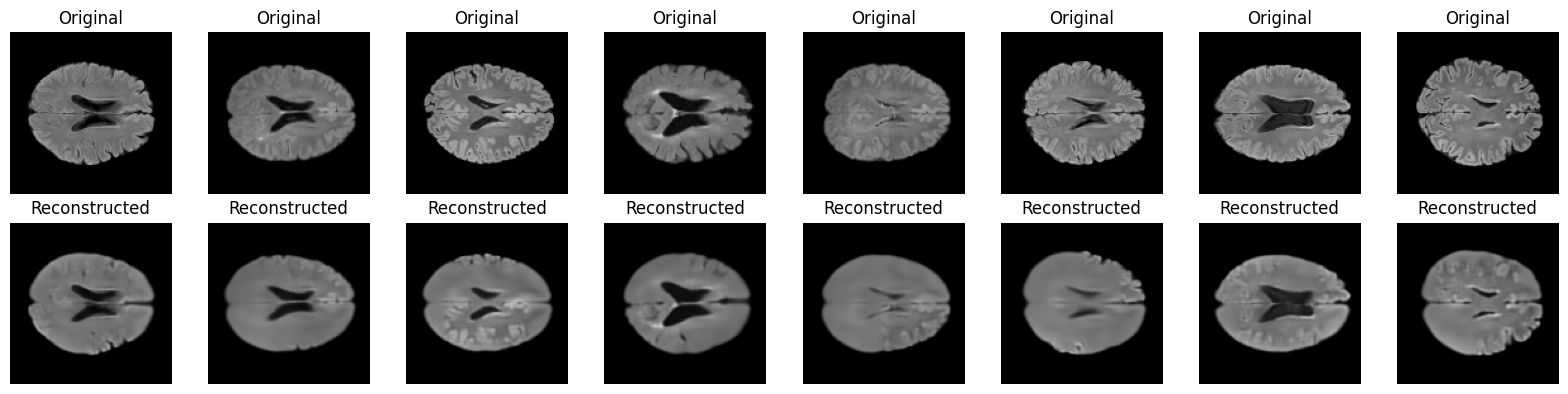

In [12]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    for batch in val_loader:
        images = batch.to(device)
        _, reco, _, _ = model(images)
        break  # only take the first batch

# Plot original and reconstructed images side by side
n = min(8, images.shape[0])
fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
for i in range(n):
    axes[0, i].imshow(images[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    axes[1, i].imshow(reco[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()